# Notebook 04 — Modeling: Disaster-Level Classification (Strategic / Budget Forecasting)
**Label:** `funding_tier` — 4 classes based on total PA obligations per disaster:
- 0 = Minor (<$1M) | 1 = Moderate ($1M–$50M) | 2 = Major ($50M–$500M) | 3 = Catastrophic (>$500M)

**Use case:** FEMA budget planning — classify total spend tier before projects are filed.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sys
sys.path.append('../')
from utils import classification_metrics, time_based_split, DISASTER_LABELS

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.base import clone

PROCESSED = '../data/processed/'
disas = pd.read_csv(PROCESSED + 'cleaned_disaster_level.csv', low_memory=False)
print('Disaster-level shape:', disas.shape)
print('Target distribution:\n', disas['funding_tier'].value_counts().sort_index())

Disaster-level shape: (1766, 20)
Target distribution:
 funding_tier
0     168
1    1301
2     229
3      68
Name: count, dtype: int64


## 4.1 Define Features & Target


In [9]:
CAT_FEATURES = ['incidentType', 'stateAbbreviation', 'incident_season']
NUM_FEATURES = [
    'declaration_lag_days',
    'incident_duration_days',
    'n_counties',
    'n_projects',
    'prior_disasters_5yr',
    'population',
    'median_income',
    'poverty_rate',
    'risk_score',
]
TARGET = 'funding_tier'

CAT_FEATURES = [c for c in CAT_FEATURES if c in disas.columns]
NUM_FEATURES = [c for c in NUM_FEATURES if c in disas.columns]
FEATURES     = CAT_FEATURES + NUM_FEATURES

df_model = disas[FEATURES + [TARGET, 'incident_year']].dropna(subset=[TARGET])
df_model[TARGET] = df_model[TARGET].astype(int)
print(f'Modeling rows: {len(df_model):,}  |  Features: {len(FEATURES)}')
print('Categorical:', CAT_FEATURES)
print('Numeric:    ', NUM_FEATURES)
print('\nClass distribution:')
for t, n in df_model[TARGET].value_counts().sort_index().items():
    print(f'  Tier {t} {DISASTER_LABELS[t]:<28} {n:>5,}  ({100*n/len(df_model):.1f}%)')

Modeling rows: 1,766  |  Features: 12
Categorical: ['incidentType', 'stateAbbreviation', 'incident_season']
Numeric:     ['declaration_lag_days', 'incident_duration_days', 'n_counties', 'n_projects', 'prior_disasters_5yr', 'population', 'median_income', 'poverty_rate', 'risk_score']

Class distribution:
  Tier 0 Minor (<$1M)                   168  (9.5%)
  Tier 1 Moderate ($1M–$50M)          1,301  (73.7%)
  Tier 2 Major ($50M–$500M)             229  (13.0%)
  Tier 3 Catastrophic (>$500M)           68  (3.9%)


## 4.2 Time-Based Train / Test Split
Train on disasters before 2018, test on 2018 onwards.
**Never use random split** on time-series data — it leaks future information into training.


In [10]:
SPLIT_YEAR = 2018
train = df_model[df_model['incident_year'] <  SPLIT_YEAR]
test  = df_model[df_model['incident_year'] >= SPLIT_YEAR]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Train years: {train["incident_year"].min()} – {train["incident_year"].max()}')
print(f'Test  years: {test["incident_year"].min()}  – {test["incident_year"].max()}')


Train: 1,202  |  Test: 564
Train years: 1998 – 2017
Test  years: 2018  – 2026


## 4.3 Preprocessing Pipeline


In [11]:
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])
preprocessor = ColumnTransformer([
    ('cat', cat_pipe, CAT_FEATURES),
    ('num', num_pipe, NUM_FEATURES)
])
print('Preprocessor defined.')


Preprocessor defined.


## 4.4 Train & Evaluate All Models


In [12]:
TARGET_NAMES = [DISASTER_LABELS[i] for i in range(4)]

models = {
    'Baseline (Stratified)': DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression':   LogisticRegression(max_iter=1000, class_weight='balanced',
                                                random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                    random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results_disaster = {}
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    m = classification_metrics(y_test.values, preds, label=name,
                               target_names=TARGET_NAMES)
    m['pipeline'] = pipe
    m['preds']    = preds
    results_disaster[name] = m


  Baseline (Stratified)
  Accuracy   :   0.5124
  F1 (wtd)   :   0.4584

                       precision    recall  f1-score   support

         Minor (<$1M)       0.17      0.11      0.13        72
  Moderate ($1M–$50M)       0.60      0.79      0.68       339
   Major ($50M–$500M)       0.21      0.11      0.15       107
Catastrophic (>$500M)       0.07      0.02      0.03        46

             accuracy                           0.51       564
            macro avg       0.26      0.26      0.25       564
         weighted avg       0.43      0.51      0.46       564


  Logistic Regression
  Accuracy   :   0.5621
  F1 (wtd)   :   0.5464

                       precision    recall  f1-score   support

         Minor (<$1M)       0.34      0.75      0.47        72
  Moderate ($1M–$50M)       0.65      0.68      0.67       339
   Major ($50M–$500M)       0.57      0.23      0.33       107
Catastrophic (>$500M)       0.89      0.17      0.29        46

             accuracy         

## 4.5 Hyperparameter Tuning — Gradient Boosting
Gradient Boosting was the strongest initial model. We run a RandomizedSearchCV using
TimeSeriesSplit (5 folds) so the CV respects temporal order within the training set.

In [13]:
# Overall summary across all models
summary = pd.DataFrame([
    {k: v for k, v in v.items() if k not in ('pipeline', 'preds')}
    for v in results_disaster.values()
]).set_index('label')
display(summary[['Accuracy', 'F1_weighted']])

# Per-class breakdown for the best model
best_name = max(results_disaster, key=lambda k: results_disaster[k]['F1_weighted'])
print(f'\nPer-class metrics — {best_name}:')
report_df = pd.DataFrame(
    classification_report(
        y_test,
        results_disaster[best_name]['preds'],
        target_names=TARGET_NAMES,
        zero_division=0,
        output_dict=True
    )
).T.round(3)
display(report_df)

,Accuracy,F1_weighted
label,,
Baseline (Stratified),0.512411,0.458435
Logistic Regression,0.562057,0.546361
Random Forest,0.632979,0.539311
Gradient Boosting,0.654255,0.594510



Per-class metrics — Gradient Boosting:


,precision,recall,f1-score,support
Minor (<$1M),0.607,0.750,0.671,72.000
Moderate ($1M–$50M),0.686,0.882,0.772,339.000
Major ($50M–$500M),0.353,0.112,0.170,107.000
Catastrophic (>$500M),0.800,0.087,0.157,46.000
accuracy,0.654,0.654,0.654,0.654
macro avg,0.611,0.458,0.442,564.000
weighted avg,0.622,0.654,0.595,564.000


## 4.6 Stability Check — Bootstrap Resampling
With only ~1,200 training rows a single split can produce a lucky or unlucky F1 estimate.
We resample the training set **with replacement** 50 times, refit the tuned model each time,
and evaluate on the same fixed test set. This gives a mean ± confidence interval, showing
whether the result is stable or a fluke of one particular split.

Bootstrapping: Gradient Boosting

Bootstrap F1_weighted over 50 resamples:
  Mean  : 0.5869
  Std   : 0.0137
  95% CI: [0.5622,  0.6097]


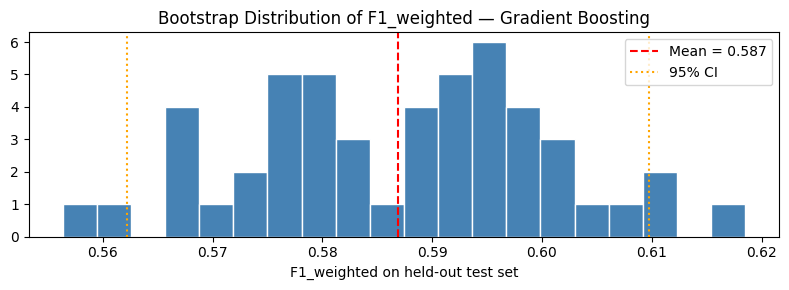

In [14]:
N_BOOTSTRAP = 50
rng = np.random.default_rng(42)
bootstrap_f1 = []

# Use whichever model currently has the best F1 (tuned if available, otherwise default GB)
best_name_boot = max(results_disaster, key=lambda k: results_disaster[k]['F1_weighted'])
best_pipe = results_disaster[best_name_boot]['pipeline']
print(f'Bootstrapping: {best_name_boot}')

for _ in range(N_BOOTSTRAP):
    idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    X_boot = X_train.iloc[idx]
    y_boot = y_train.iloc[idx]
    pipe_boot = clone(best_pipe)
    pipe_boot.fit(X_boot, y_boot)
    preds_boot = pipe_boot.predict(X_test)
    bootstrap_f1.append(f1_score(y_test, preds_boot, average='weighted', zero_division=0))

bootstrap_f1 = np.array(bootstrap_f1)
print(f'\nBootstrap F1_weighted over {N_BOOTSTRAP} resamples:')
print(f'  Mean  : {bootstrap_f1.mean():.4f}')
print(f'  Std   : {bootstrap_f1.std():.4f}')
print(f'  95% CI: [{np.percentile(bootstrap_f1, 2.5):.4f},  {np.percentile(bootstrap_f1, 97.5):.4f}]')

plt.figure(figsize=(8, 3))
plt.hist(bootstrap_f1, bins=20, color='steelblue', edgecolor='white')
plt.axvline(bootstrap_f1.mean(), color='red',    linestyle='--',
            label=f'Mean = {bootstrap_f1.mean():.3f}')
plt.axvline(np.percentile(bootstrap_f1, 2.5),  color='orange', linestyle=':',
            label='95% CI')
plt.axvline(np.percentile(bootstrap_f1, 97.5), color='orange', linestyle=':')
plt.title(f'Bootstrap Distribution of F1_weighted — {best_name_boot}')
plt.xlabel('F1_weighted on held-out test set')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/bootstrap_f1_disaster.png', dpi=150)
plt.show()

## 4.5 Results Summary Table


In [15]:
summary = pd.DataFrame([
    {k: v for k, v in v.items() if k not in ('pipeline', 'preds')}
    for v in results_disaster.values()
]).set_index('label')
summary[['Accuracy', 'F1_weighted']]

,Accuracy,F1_weighted
label,,
Baseline (Stratified),0.512411,0.458435
Logistic Regression,0.562057,0.546361
Random Forest,0.632979,0.539311
Gradient Boosting,0.654255,0.594510


## 4.6 Feature Importances — Random Forest


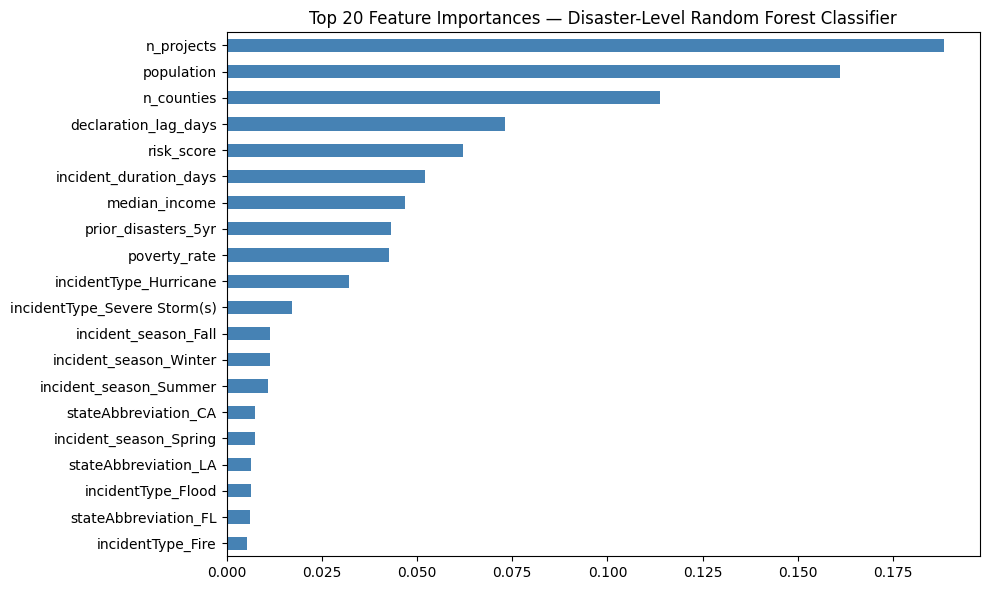

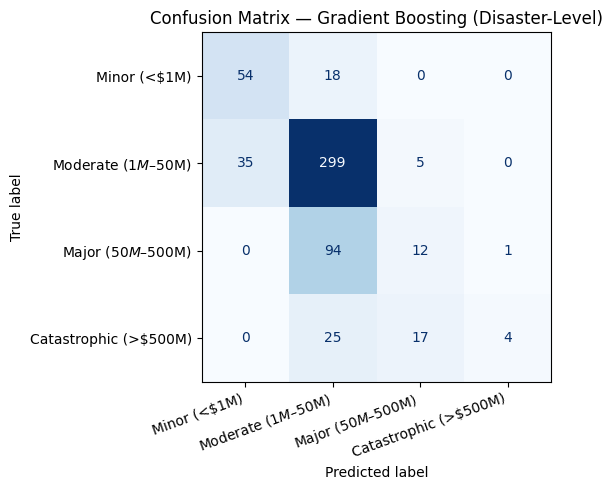

In [16]:
rf_pipe  = results_disaster['Random Forest']['pipeline']
rf_model = rf_pipe.named_steps['model']
rf_pre   = rf_pipe.named_steps['pre']

ohe_names = rf_pre.transformers_[0][1].named_steps['ohe'].get_feature_names_out(CAT_FEATURES)
all_names = list(ohe_names) + NUM_FEATURES

importances = pd.Series(rf_model.feature_importances_, index=all_names)
importances.nlargest(20).sort_values().plot(
    kind='barh', figsize=(10, 6),
    title='Top 20 Feature Importances — Disaster-Level Random Forest Classifier',
    color='steelblue'
)
plt.tight_layout()
plt.savefig('../data/processed/feature_importance_disaster.png', dpi=150)
plt.show()

# Confusion matrix for best model
best_name = max(results_disaster, key=lambda k: results_disaster[k]['F1_weighted'])
cm = confusion_matrix(y_test, results_disaster[best_name]['preds'])
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name} (Disaster-Level)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_disaster.png', dpi=150)
plt.show()

## 4.7 Save Best Pipeline


In [17]:
best_name = max(results_disaster, key=lambda k: results_disaster[k]['F1_weighted'])
print(f'Best model: {best_name}  (F1_weighted = {results_disaster[best_name]["F1_weighted"]:.4f})')

with open(PROCESSED + 'best_disaster_model.pkl', 'wb') as f:
    pickle.dump({
        'pipeline':     results_disaster[best_name]['pipeline'],
        'X_test':       X_test,
        'y_test':       y_test,
        'preds':        results_disaster[best_name]['preds'],
        'features':     FEATURES,
        'cat_features': CAT_FEATURES,
        'num_features': NUM_FEATURES,
        'target_names': TARGET_NAMES,
        'model_name':   best_name,
        'level':        'disaster',
    }, f)
print('Saved best_disaster_model.pkl')

Best model: Gradient Boosting  (F1_weighted = 0.5945)
Saved best_disaster_model.pkl
